# 07 - Day 3: Zero-Day / Unseen-Attack Detection

**Day 3 - Cross-Temporal Hybrid NIDS**

Continues directly from Day 1 (Random Forest baseline) and Day 2
(validation-based thresholding, IsolationForest, hybrid detector).
Does **not** retrain or modify anything from Day 1 or Day 2 -- all
three detectors are loaded exactly as already frozen and evaluated
as-is.

## What "zero-day / unseen attack" means here

An attack class is treated as **unseen** only if it is completely
absent from the full Monday-Thursday supervised training period --
the same data the Random Forest baseline was actually fit on (`data/processed/day1/train.parquet`).
A class is **seen** if it appears anywhere in that period, even if
most of its Friday traffic looks different.

## Why Friday alone is not automatically "zero-day"

Day 1/Day 2 already established Friday as a frozen *temporal* holdout,
but several Friday attack classes (e.g. `DoS Hulk`-style classes) may
also appear during Monday-Thursday. Those classes are cross-temporal
generalization tests, not zero-day tests. Day 3 explicitly separates
the two by computing a class inventory (`src.day3.zero_day.class_inventory`)
before evaluating anything.

## How thresholds were frozen

No threshold is selected or tuned in this notebook.

- **Random Forest**: reuses Day 1's already-established frozen threshold,
  `RF_DAY1_FROZEN_THRESHOLD = 0.01`.
- **IsolationForest** and **Hybrid**: reuse the thresholds Day 2 already
  selected from Thursday validation (`results/day2/validation_threshold_selection.json`).

Unseen-attack rows are **never** used for threshold selection -- this
notebook does not import `select_threshold_from_validation` at all.

## Why IsolationForest is relevant here

IsolationForest was fit only on a mostly-benign sample of Monday-Thursday
traffic. It has no notion of attack *classes* -- it only measures how
anomalous a row looks relative to that benign distribution. That makes
it a natural fit for zero-day analysis: it doesn't need to have seen a
class to flag it as anomalous, unlike a supervised classifier.

## Why the Random Forest is still evaluated

The Random Forest was trained with a **binary** benign/attack label.
Even though it was never trained to recognize any specific unseen
class, its binary "is this attack-like" signal can still potentially
fire on unseen-class traffic if that traffic resembles other attacks
it has seen. This notebook tests that directly -- it does **not**
assume the RF will fail.

## Why the hybrid is evaluated without retuning

The hybrid combines RF probability (70%) and the anomaly score (30%)
using the same frozen 0.7/0.3 weighting and frozen threshold Day 2
already established. If it performs poorly on unseen attacks, that is
reported honestly below -- it is a scientifically useful negative
result, not something to hide or re-tune away.

**Requires** (already produced by Day 1 and Day 2, not regenerated here):
- `data/processed/day1/train.parquet`, `test.parquet`, `split_metadata.json`
- `models/day1/random_forest_baseline.joblib`
- `models/day2/isolation_forest.joblib`, `models/day2/day2_metadata.json`
- `results/day2/validation_threshold_selection.json`


## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils.validation import check_is_fitted

from src.data.validator import validate_nan_inf
from src.day2.anomaly import AnomalyModel, anomaly_scores
from src.day2.hybrid import HybridConfig, combine_scores, hybrid_predict
from src.day2.thresholding import (
    RF_DAY1_FROZEN_THRESHOLD,
    evaluate_frozen_threshold,
    per_class_frozen_results,
)
from src.day3.zero_day import (
    assert_feature_alignment,
    assert_no_unseen_leakage,
    build_population,
    class_inventory,
)

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "day1"
DAY1_MODEL_DIR = PROJECT_ROOT / "models" / "day1"
DAY2_MODEL_DIR = PROJECT_ROOT / "models" / "day2"
DAY2_RESULTS_DIR = PROJECT_ROOT / "results" / "day2"
RESULTS_DIR = PROJECT_ROOT / "results" / "day3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Fallback thresholds, used ONLY if results/day2/validation_threshold_selection.json
# is missing. Mirror Day 2's already-established values; not re-derived here.
FALLBACK_IF_THRESHOLD = 0.15
FALLBACK_HYBRID_THRESHOLD = 0.50

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-


## 1. Load Day 1 + Day 2 artifacts (not regenerated, not retrained)

This step **stops** rather than fabricating a zero-day experiment if
any required artifact is missing.

In [2]:
train_path = DATA_DIR / "train.parquet"
test_path = DATA_DIR / "test.parquet"
metadata_path = DATA_DIR / "split_metadata.json"
rf_model_path = DAY1_MODEL_DIR / "random_forest_baseline.joblib"
if_model_path = DAY2_MODEL_DIR / "isolation_forest.joblib"
day2_threshold_path = DAY2_RESULTS_DIR / "validation_threshold_selection.json"
day2_metadata_path = DAY2_MODEL_DIR / "day2_metadata.json"

required = [train_path, test_path, metadata_path, rf_model_path, if_model_path]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Day 3 requires existing Day 1 and Day 2 artifacts. Missing: {missing}. "
        "Run Day 1's scripts/prepare_data.py + scripts/train_baseline.py and "
        "Day 2's scripts/run_day2.py first."
    )

metadata = json.loads(metadata_path.read_text())
feature_names = metadata["feature_names"]

train_df = pd.read_parquet(train_path)   # Monday-Thursday, FULL supervised training period
test_df = pd.read_parquet(test_path)     # Friday -- frozen, read-only
rf_model = joblib.load(rf_model_path)
if_raw_model = joblib.load(if_model_path)

print("Train shape:", train_df.shape)
print("Test (Friday) shape:", test_df.shape)
print("Number of features:", len(feature_names))


Train shape: (1796986, 75)
Test (Friday) shape: (516824, 75)
Number of features: 58


## 2. Research-integrity checks

These run *before* either model ever sees Friday, and prove:
- both models are pre-fitted (loaded), not fit in this notebook
- the evaluation feature columns match what each model was fit on

In [3]:
check_is_fitted(rf_model)
check_is_fitted(if_raw_model)
print("Integrity check passed: RF and IsolationForest are pre-fitted, loaded models.")

assert_feature_alignment(feature_names, rf_model, context="Random Forest baseline")
assert_feature_alignment(feature_names, if_raw_model, context="IsolationForest")
print("Integrity check passed: feature columns match the fitted models.")


Integrity check passed: RF and IsolationForest are pre-fitted, loaded models.
Integrity check passed: feature columns match the fitted models.


## 3. Class inventory -- seen vs. unseen vs. benign

Computed from the **full** Monday-Thursday training period (what the
Random Forest actually saw), not any smaller internal sub-split.

In [4]:
inventory = class_inventory(train_df, test_df)
print(json.dumps(inventory.summary(), indent=2))

assert_no_unseen_leakage(train_df, inventory.unseen_attack_classes)
print("\nIntegrity check passed: no unseen-flagged class appears in training data.")

if not inventory.unseen_attack_classes:
    raise RuntimeError(
        "No Friday attack class is absent from Monday-Thursday training -- "
        "there is no genuine zero-day population to evaluate. Stopping "
        "rather than fabricating one."
    )


{
  "label_col": "label_multiclass",
  "benign_label": "Benign",
  "train_classes": [
    "Benign",
    "DoS GoldenEye",
    "DoS Hulk",
    "DoS Slowhttptest",
    "DoS slowloris",
    "FTP-Patator",
    "Heartbleed",
    "Infiltration",
    "SSH-Patator",
    "Web Attack \ufffd Brute Force",
    "Web Attack \ufffd Sql Injection",
    "Web Attack \ufffd XSS"
  ],
  "test_classes": [
    "Benign",
    "Bot",
    "DDoS",
    "PortScan"
  ],
  "seen_attack_classes": [
    "DoS GoldenEye",
    "DoS Hulk",
    "DoS Slowhttptest",
    "DoS slowloris",
    "FTP-Patator",
    "Heartbleed",
    "Infiltration",
    "SSH-Patator",
    "Web Attack \ufffd Brute Force",
    "Web Attack \ufffd Sql Injection",
    "Web Attack \ufffd XSS"
  ],
  "unseen_attack_classes": [
    "Bot",
    "DDoS",
    "PortScan"
  ],
  "n_seen_attack_classes": 11,
  "n_unseen_attack_classes": 3,
  "note": "train_classes/seen_attack_classes are computed from the FULL Monday-Thursday training period (the data the Random Fo

## 4. NaN/Inf check on Friday (reused from Day 1's validator)

In [5]:
nan_inf_report = validate_nan_inf(test_df[feature_names])
print("has_nan:", nan_inf_report.has_nan, " has_inf:", nan_inf_report.has_inf)


NaN values found in columns: {'Flow Duration': 21}


has_nan: True  has_inf: False


## 5. Reconstruct the IsolationForest scoring wrapper

Reuses `src.day2.anomaly.anomaly_scores` unmodified. Training medians
are recomputed from the full Monday-Thursday data (same imputation
strategy Day 1/Day 2 already use) since Day 2's exact anomaly-training
*sample* medians were not persisted -- NaNs are rare (Day 1: 124/1.8M
rows), so this is a documented, negligible approximation, not a
methodology change.

In [6]:
train_medians = train_df[feature_names].median(numeric_only=True)

if_config = {}
if day2_metadata_path.exists():
    day2_metadata = json.loads(day2_metadata_path.read_text())
    if_config = day2_metadata.get("isolation_forest_config", {})

anomaly_model = AnomalyModel(
    model=if_raw_model,
    feature_names=list(feature_names),
    train_medians=train_medians,
    contamination=if_config.get("contamination", if_raw_model.get_params().get("contamination")),
    n_estimators=if_config.get("n_estimators", if_raw_model.get_params().get("n_estimators")),
    random_state=if_config.get("random_state", if_raw_model.get_params().get("random_state")),
    n_training_samples=if_config.get("n_training_samples", -1),
)
print(anomaly_model.config_summary())


{'model_type': 'IsolationForest', 'contamination': 0.05, 'n_estimators': 100, 'random_state': 42, 'n_training_samples': 100000, 'n_features': 58}


## 6. Frozen thresholds -- read, not selected

RF uses Day 1's `RF_DAY1_FROZEN_THRESHOLD`. IsolationForest/Hybrid read
their thresholds from Day 2's saved `validation_threshold_selection.json`
(falling back to Day 2's documented values only if that file is
missing). Nothing is re-selected here.

In [7]:
rf_threshold = RF_DAY1_FROZEN_THRESHOLD

if day2_threshold_path.exists():
    day2_thresholds = json.loads(day2_threshold_path.read_text())
    if_threshold = day2_thresholds["isolation_forest"]["selected_threshold"]
    hybrid_threshold = day2_thresholds["hybrid"]["selected_threshold"]
    threshold_source = str(day2_threshold_path)
else:
    print(f"WARNING: {day2_threshold_path} not found -- using documented Day 2 fallback thresholds.")
    if_threshold = FALLBACK_IF_THRESHOLD
    hybrid_threshold = FALLBACK_HYBRID_THRESHOLD
    threshold_source = "fallback_default"

hybrid_config = HybridConfig(threshold=hybrid_threshold)  # rf_weight/anomaly_weight left at Day 2 defaults (0.7/0.3)

print(f"RF threshold (Day 1 frozen): {rf_threshold}")
print(f"IsolationForest threshold (Day 2 frozen): {if_threshold}")
print(f"Hybrid threshold (Day 2 frozen): {hybrid_threshold}")
print(f"Threshold source: {threshold_source}")


RF threshold (Day 1 frozen): 0.01
IsolationForest threshold (Day 2 frozen): 0.15
Hybrid threshold (Day 2 frozen): 0.5
Threshold source: c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\results\day2\validation_threshold_selection.json


## 7. Score Friday once with each detector

In [8]:
X_test = test_df[feature_names].fillna(train_medians)
assert not X_test.isna().any().any(), "NaNs remain after imputation -- aborting."
assert not np.isinf(X_test.to_numpy()).any(), "Inf values present after imputation -- aborting."

y_test = test_df["label_binary"].astype(int)
test_proba = rf_model.predict_proba(X_test)[:, 1]
test_anomaly = anomaly_scores(anomaly_model, test_df)
test_hybrid = combine_scores(test_proba, test_anomaly, hybrid_config)

test_pred_rf = (test_proba >= rf_threshold).astype(int)
test_pred_if = (test_anomaly >= if_threshold).astype(int)
test_pred_hybrid = hybrid_predict(test_hybrid, hybrid_threshold)

print("Scored", len(test_df), "Friday rows with RF, IsolationForest, and Hybrid.")


Scored 516824 Friday rows with RF, IsolationForest, and Hybrid.


## 8. Zero-day evaluation -- kept-separate populations

- **A. all_friday** -- full Friday (seen + unseen + benign)
- **B. unseen_attacks_vs_benign** -- unseen classes + benign only
- **C. one row per unseen class** -- that class + benign only

These populations are never mixed together.

In [9]:
populations = {"all_friday": test_df}
populations["unseen_attacks_vs_benign"] = build_population(
    test_df, inventory.unseen_attack_classes, inventory.benign_label
)
for cls in inventory.unseen_attack_classes:
    populations[f"unseen__{cls}"] = build_population(test_df, [cls], inventory.benign_label)

detector_scores = {
    "random_forest": (test_proba, rf_threshold),
    "isolation_forest": (test_anomaly, if_threshold),
    "hybrid": (test_hybrid, hybrid_threshold),
}

comparison_rows = []
for pop_name, pop_df in populations.items():
    pop_positions = test_df.index.get_indexer(pop_df.index)
    pop_y = y_test.to_numpy()[pop_positions]
    for detector_name, (scores, threshold) in detector_scores.items():
        pop_scores = np.asarray(scores)[pop_positions]
        metrics = evaluate_frozen_threshold(pop_y, pop_scores, threshold)
        comparison_rows.append({
            "detector": detector_name, "population": pop_name,
            "n_samples": len(pop_df), "threshold_used": threshold, **metrics,
        })

comparison = pd.DataFrame(comparison_rows)
comparison


,detector,population,n_samples,threshold_used,threshold,precision,recall,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,pr_auc
0,random_forest,all_friday,516824,0.01,0.01,0.823470,0.881856,0.851663,0.064455,0.118144,360575,24842,15525,115882,0.969470,0.910076
1,isolation_forest,all_friday,516824,0.15,0.15,0.441698,0.762524,0.559374,0.328613,0.237476,258764,126653,31206,100201,0.784616,0.448362
2,hybrid,all_friday,516824,0.50,0.50,0.493750,0.000601,0.001201,0.000210,0.999399,385336,81,131328,79,0.852395,0.731481
3,random_forest,unseen_attacks_vs_benign,516824,0.01,0.01,0.823470,0.881856,0.851663,0.064455,0.118144,360575,24842,15525,115882,0.969470,0.910076
4,isolation_forest,unseen_attacks_vs_benign,516824,0.15,0.15,0.441698,0.762524,0.559374,0.328613,0.237476,258764,126653,31206,100201,0.784616,0.448362
5,hybrid,unseen_attacks_vs_benign,516824,0.50,0.50,0.493750,0.000601,0.001201,0.000210,0.999399,385336,81,131328,79,0.852395,0.731481
6,random_forest,unseen__Bot,386854,0.01,0.01,0.012796,0.224078,0.024210,0.064455,0.775922,360575,24842,1115,322,0.712409,0.009826
7,isolation_forest,unseen__Bot,386854,0.15,0.15,0.001065,0.093946,0.002106,0.328613,0.906054,258764,126653,1302,135,0.511813,0.004167
8,hybrid,unseen__Bot,386854,0.50,0.50,0.000000,0.000000,0.000000,0.000210,1.000000,385336,81,1437,0,0.521413,0.003941
9,random_forest,unseen__DDoS,513431,0.01,0.01,0.821462,0.892863,0.855676,0.064455,0.107137,360575,24842,13715,114299,0.974955,0.915391


## 9. Per-class detection rates (unseen classes only, no benign mixed in)

Precision/FPR are not meaningful for a pure-attack population, so this
table reports detection rate only, per the Day 3 brief.

In [10]:
unseen_mask = test_df["label_multiclass"].isin(inventory.unseen_attack_classes)
unseen_classes_series = test_df.loc[unseen_mask, "label_multiclass"]

per_class_tables = {}
for detector_name, (scores, threshold) in detector_scores.items():
    scores_arr = np.asarray(scores)[unseen_mask.to_numpy()]
    preds_arr = (scores_arr >= threshold).astype(int)
    table = per_class_frozen_results(scores_arr, preds_arr, unseen_classes_series)
    table["pct_detected"] = table["detection_rate"] * 100.0
    table["pct_missed"] = (1 - table["detection_rate"]) * 100.0
    per_class_tables[detector_name] = table

per_class_wide = per_class_tables["random_forest"][["class", "samples", "predicted_attack", "detection_rate"]].rename(
    columns={"predicted_attack": "RF_detected", "detection_rate": "RF_detection_rate", "class": "attack_class"}
)
for detector_name, prefix in [("isolation_forest", "IF"), ("hybrid", "hybrid")]:
    t = per_class_tables[detector_name][["class", "predicted_attack", "detection_rate"]].rename(
        columns={"predicted_attack": f"{prefix}_detected", "detection_rate": f"{prefix}_detection_rate", "class": "attack_class"}
    )
    per_class_wide = per_class_wide.merge(t, on="attack_class", how="left")

detection_rates_long = pd.concat(
    [table.assign(detector=name)[["detector", "class", "samples", "predicted_attack", "detection_rate", "pct_detected", "pct_missed"]]
     for name, table in per_class_tables.items()],
    ignore_index=True,
).rename(columns={"class": "attack_class", "predicted_attack": "detected"})

per_class_wide


,attack_class,samples,RF_detected,RF_detection_rate,IF_detected,IF_detection_rate,hybrid_detected,hybrid_detection_rate
0,DDoS,128014,114299,0.892863,99431,0.776720,14,0.000109
1,PortScan,1956,1261,0.644683,635,0.324642,65,0.033231
2,Bot,1437,322,0.224078,135,0.093946,0,0.000000


## 10. Visualizations

### 10.1 Detection rate by unseen attack class

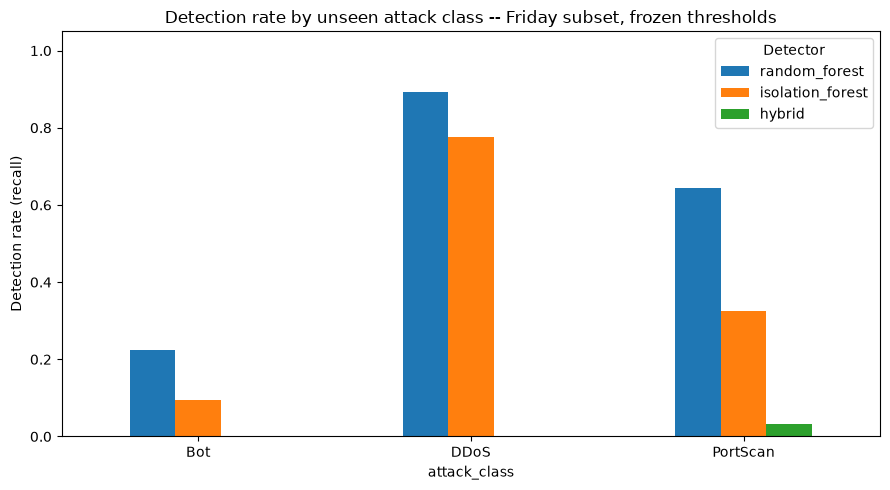

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = detection_rates_long.pivot(index="attack_class", columns="detector", values="detection_rate")
pivot = pivot[["random_forest", "isolation_forest", "hybrid"]]
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Detection rate (recall)")
ax.set_title("Detection rate by unseen attack class -- Friday subset, frozen thresholds")
ax.set_ylim(0, 1.05)
ax.legend(title="Detector")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 10.2 Random Forest score distribution: benign vs. unseen attacks

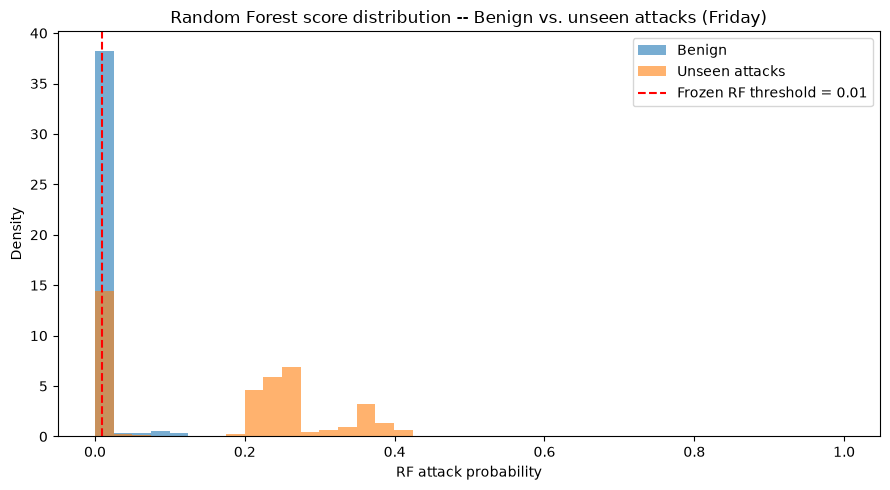

In [12]:
benign_mask = (test_df["label_multiclass"] == inventory.benign_label).to_numpy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_proba[benign_mask], bins=40, alpha=0.6, label="Benign", density=True)
ax.hist(test_proba[unseen_mask.to_numpy()], bins=40, alpha=0.6, label="Unseen attacks", density=True)
ax.axvline(rf_threshold, color="red", linestyle="--", label=f"Frozen RF threshold = {rf_threshold}")
ax.set_xlabel("RF attack probability")
ax.set_ylabel("Density")
ax.set_title("Random Forest score distribution -- Benign vs. unseen attacks (Friday)")
ax.legend()
plt.tight_layout()
plt.show()


### 10.3 IsolationForest score distribution: benign vs. unseen attacks

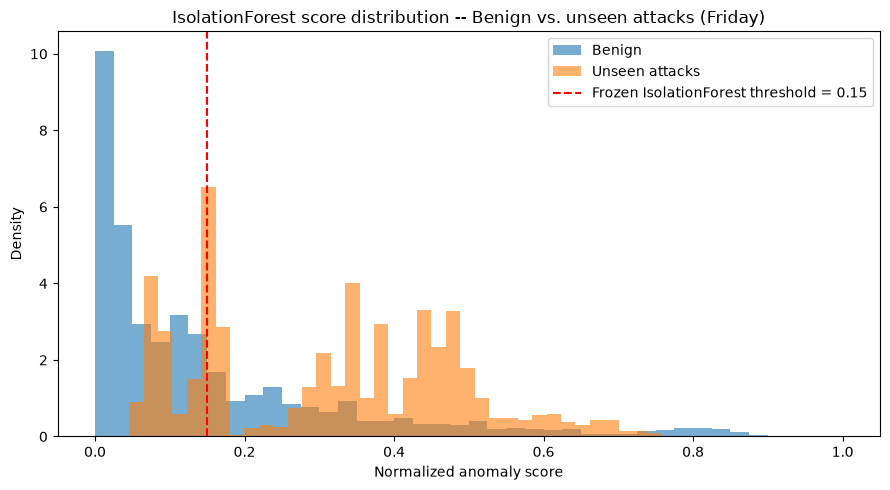

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_anomaly[benign_mask], bins=40, alpha=0.6, label="Benign", density=True)
ax.hist(test_anomaly[unseen_mask.to_numpy()], bins=40, alpha=0.6, label="Unseen attacks", density=True)
ax.axvline(if_threshold, color="red", linestyle="--", label=f"Frozen IsolationForest threshold = {if_threshold}")
ax.set_xlabel("Normalized anomaly score")
ax.set_ylabel("Density")
ax.set_title("IsolationForest score distribution -- Benign vs. unseen attacks (Friday)")
ax.legend()
plt.tight_layout()
plt.show()


### 10.4 Hybrid score distribution: benign vs. unseen attacks

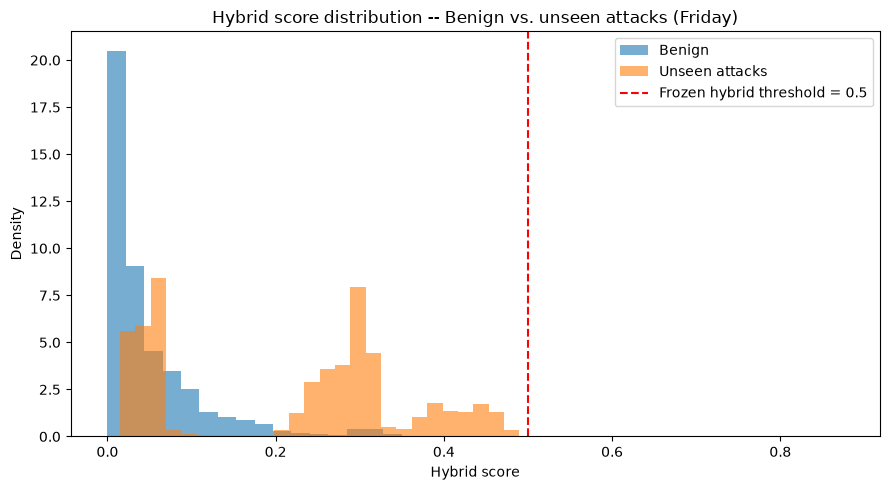

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_hybrid[benign_mask], bins=40, alpha=0.6, label="Benign", density=True)
ax.hist(test_hybrid[unseen_mask.to_numpy()], bins=40, alpha=0.6, label="Unseen attacks", density=True)
ax.axvline(hybrid_threshold, color="red", linestyle="--", label=f"Frozen hybrid threshold = {hybrid_threshold}")
ax.set_xlabel("Hybrid score")
ax.set_ylabel("Density")
ax.set_title("Hybrid score distribution -- Benign vs. unseen attacks (Friday)")
ax.legend()
plt.tight_layout()
plt.show()


### 10.5 Detector comparison: unseen-attack recall and F1

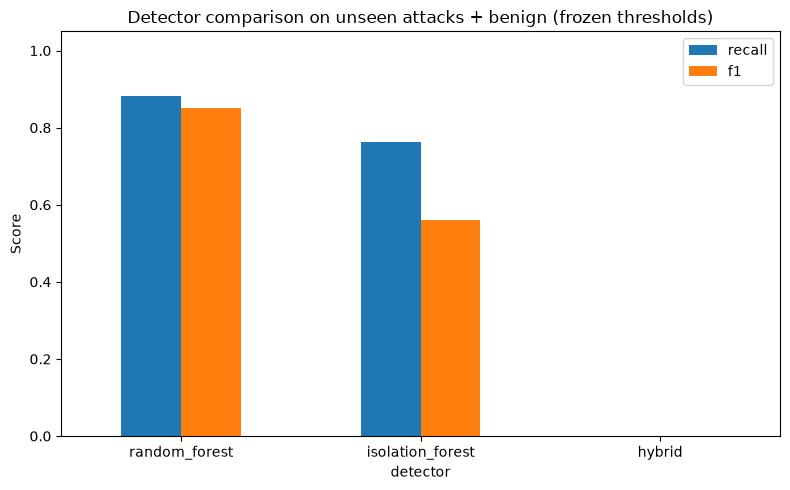

In [15]:
unseen_pop_metrics = comparison[comparison["population"] == "unseen_attacks_vs_benign"].set_index("detector")
fig, ax = plt.subplots(figsize=(8, 5))
unseen_pop_metrics[["recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Detector comparison on unseen attacks + benign (frozen thresholds)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Automatic research interpretation

Rule-based on the numbers actually computed above -- does not force a
positive result.

In [16]:
def _recall_for(detector_name):
    row = comparison[(comparison["detector"] == detector_name) & (comparison["population"] == "unseen_attacks_vs_benign")]
    return float(row["recall"].iloc[0]) if len(row) else float("nan")

rf_recall = _recall_for("random_forest")
if_recall = _recall_for("isolation_forest")
hybrid_recall = _recall_for("hybrid")

interpretation_lines = [
    f"Unseen attack classes identified: {inventory.unseen_attack_classes} (absent from the full Monday-Thursday training period).",
    f"Random Forest (binary, frozen threshold={rf_threshold}) recall on unseen attacks + benign: {rf_recall:.4f}.",
    f"IsolationForest (frozen threshold={if_threshold}) recall on unseen attacks + benign: {if_recall:.4f}.",
    f"Hybrid (frozen threshold={hybrid_threshold}) recall on unseen attacks + benign: {hybrid_recall:.4f}.",
]

if not any(np.isnan([rf_recall, if_recall, hybrid_recall])):
    best_name, best_recall = max(
        [("Random Forest", rf_recall), ("IsolationForest", if_recall), ("Hybrid", hybrid_recall)],
        key=lambda pair: pair[1],
    )
    interpretation_lines.append(f"Highest unseen-attack recall: {best_name} ({best_recall:.4f}).")

    if if_recall > rf_recall:
        interpretation_lines.append(
            "The anomaly detector (IsolationForest) detects unseen attack traffic at a higher rate "
            "than the binary Random Forest here, consistent with the hypothesis that anomaly-based "
            "detection can generalize better to attack behavior absent from supervised training."
        )
    else:
        interpretation_lines.append(
            "The Random Forest's binary attack/benign signal still detects unseen attack traffic at "
            "least as well as IsolationForest here -- i.e. binary 'is this attack-like' generalization "
            "from RF extends to some unseen classes, even though RF cannot name them (see multiclass caveat below)."
        )

    if hybrid_recall < min(rf_recall, if_recall) - 0.05:
        interpretation_lines.append(
            "The hybrid detector performs worse than BOTH individual detectors on unseen attacks. "
            "This is a negative result and is reported as-is: at its current frozen threshold and "
            "0.7/0.3 weighting, combining the two signals does not help, and may hurt, zero-day "
            "detection -- consistent with the RF-dominated hybrid formula inheriting the RF's "
            "degraded confidence on temporally-shifted traffic (see Day 2 findings)."
        )
    elif hybrid_recall > max(rf_recall, if_recall):
        interpretation_lines.append("The hybrid detector improves unseen-attack recall over both individual detectors here.")
    else:
        interpretation_lines.append(
            "The hybrid detector's unseen-attack recall falls between the two individual detectors "
            "-- it neither clearly helps nor clearly fails here."
        )

interpretation_lines.append(
    "Multiclass caveat: the Random Forest was trained with a BINARY (benign/attack) label, so even "
    "if it flags unseen-class traffic as 'attack', it was never trained to name that class -- "
    "multiclass identification of a truly unseen class is not possible for a classifier that never "
    "saw any example of it, by definition."
)

print("=== Day 3 Research Interpretation ===")
for line in interpretation_lines:
    print("-", line)


=== Day 3 Research Interpretation ===
- Unseen attack classes identified: ['Bot', 'DDoS', 'PortScan'] (absent from the full Monday-Thursday training period).
- Random Forest (binary, frozen threshold=0.01) recall on unseen attacks + benign: 0.8819.
- IsolationForest (frozen threshold=0.15) recall on unseen attacks + benign: 0.7625.
- Hybrid (frozen threshold=0.5) recall on unseen attacks + benign: 0.0006.
- Highest unseen-attack recall: Random Forest (0.8819).
- The Random Forest's binary attack/benign signal still detects unseen attack traffic at least as well as IsolationForest here -- i.e. binary 'is this attack-like' generalization from RF extends to some unseen classes, even though RF cannot name them (see multiclass caveat below).
- The hybrid detector performs worse than BOTH individual detectors on unseen attacks. This is a negative result and is reported as-is: at its current frozen threshold and 0.7/0.3 weighting, combining the two signals does not help, and may hurt, zero-da

## 12. Save outputs (results/day3 only)

In [17]:
zero_day_summary = {
    "class_inventory": inventory.summary(),
    "thresholds_used": {
        "random_forest": rf_threshold, "isolation_forest": if_threshold, "hybrid": hybrid_threshold,
        "source": threshold_source,
        "note": "All thresholds reused from Day 1/Day 2 frozen values; none selected or tuned in Day 3.",
    },
    "hybrid_config": hybrid_config.summary(),
    "nan_inf_report_friday_raw": nan_inf_report.to_dict(),
    "integrity_checks_passed": [
        "rf_and_if_pre_fitted_before_test_access", "feature_alignment_rf", "feature_alignment_isolation_forest",
        "no_unseen_class_in_training_data", "no_nan_or_inf_after_imputation",
    ],
    "research_interpretation": interpretation_lines,
}
(RESULTS_DIR / "zero_day_summary.json").write_text(json.dumps(zero_day_summary, indent=2, default=str))
comparison.to_csv(RESULTS_DIR / "zero_day_comparison.csv", index=False)
per_class_wide.to_csv(RESULTS_DIR / "zero_day_per_class.csv", index=False)
detection_rates_long.to_csv(RESULTS_DIR / "zero_day_detection_rates.csv", index=False)

day3_metadata = {
    "inputs": {
        "train_path": str(train_path), "test_path": str(test_path),
        "rf_model_path": str(rf_model_path), "if_model_path": str(if_model_path),
        "day2_threshold_source": threshold_source,
    },
    "feature_names": feature_names, "n_features": len(feature_names),
    "class_inventory": inventory.summary(), "populations_evaluated": list(populations.keys()),
}
(RESULTS_DIR / "day3_metadata.json").write_text(json.dumps(day3_metadata, indent=2, default=str))

print("Day 3 outputs written to:", RESULTS_DIR)


Day 3 outputs written to: c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\results\day3
